# Receipt Scanner

An AI-powered receipt scanner that extracts structured data from photos of receipts.

**What this project demonstrates:**
- OpenAI Vision API (gpt-4o) for image understanding
- Base64 image encoding for API integration
- Structured prompt engineering for consistent JSON output
- Real-world application of vision models

Built as part of Module 2 (Vision GPT) of the LLM & Agentic AI Bootcamp.

## Setup

In [1]:
import os
import io
import json
import base64
from dotenv import load_dotenv
from openai import OpenAI
from PIL import Image
from IPython.display import display, Markdown

load_dotenv()
client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))
print("Client ready!")

Client ready!


## Image Encoding

OpenAI's Vision API requires images as base64-encoded strings.
This helper converts both file paths and PIL Image objects.

In [2]:
def encode_image(image_path_or_pil):
    """Convert an image file or PIL object to base64 string."""
    if isinstance(image_path_or_pil, str):
        if not os.path.exists(image_path_or_pil):
            raise FileNotFoundError(f"Image not found: {image_path_or_pil}")
        with open(image_path_or_pil, "rb") as f:
            return base64.b64encode(f.read()).decode("utf-8")
    elif isinstance(image_path_or_pil, Image.Image):
        buffer = io.BytesIO()
        image_format = image_path_or_pil.format or "PNG"
        image_path_or_pil.save(buffer, format=image_format)
        return base64.b64encode(buffer.getvalue()).decode("utf-8")
    else:
        raise ValueError("Input must be a file path or PIL Image object.")

## The Structured Prompt

The key technique from Module 2: a well-structured prompt with **context**, **instruction**,
**input**, and **output format** ensures the model returns consistent, parseable JSON.

In [3]:
RECEIPT_PROMPT = """
# Receipt Data Extraction

## Context
You are an expert OCR and data extraction system specialized in reading receipts.

## Instruction
Analyze the receipt image and extract all relevant information into a structured format.

## Input
- A photo of a receipt (may be crumpled, tilted, or partially blurry)

## Output
Respond ONLY with a JSON object containing these fields:
- store_name (string): name of the store or restaurant
- date (string): date of purchase (format: YYYY-MM-DD, or null if not visible)
- items (array of objects): each with "name" (string), "quantity" (number), "price" (number)
- subtotal (number or null)
- tax (number or null)
- total (number): the total amount paid
- currency (string): e.g. "EUR", "USD", "GBP"
- payment_method (string or null): e.g. "cash", "card", "contactless"
- confidence (string): "High", "Medium", or "Low" based on image readability

Example:
{
  "store_name": "Conad City",
  "date": "2026-03-01",
  "items": [
    {"name": "Pasta Barilla", "quantity": 2, "price": 1.89},
    {"name": "Mozzarella", "quantity": 1, "price": 2.50}
  ],
  "subtotal": 6.28,
  "tax": 0.63,
  "total": 6.91,
  "currency": "EUR",
  "payment_method": "card",
  "confidence": "High"
}

IMPORTANT: Respond ONLY with the JSON object. No extra text.
"""

print("Prompt ready!")

Prompt ready!


## The Scanner Function

This function sends the receipt image to OpenAI's Vision API and parses the JSON response.

In [4]:
def scan_receipt(image_path, model="gpt-4o", max_tokens=1000):
    """Scan a receipt image and return structured data."""
    # Load and display the image
    img = Image.open(image_path)
    print(f"Image: {image_path} ({img.size[0]}x{img.size[1]})")
    display(img)
    
    # Encode to base64
    b64_image = encode_image(img)
    
    # Call Vision API
    response = client.chat.completions.create(
        model=model,
        messages=[
            {
                "role": "user",
                "content": [
                    {"type": "text", "text": RECEIPT_PROMPT},
                    {
                        "type": "image_url",
                        "image_url": {
                            "url": f"data:image/png;base64,{b64_image}"
                        }
                    }
                ]
            }
        ],
        max_tokens=max_tokens
    )
    
    # Token usage
    usage = response.usage
    print(f"\nTokens - Prompt: {usage.prompt_tokens}, Response: {usage.completion_tokens}, Total: {usage.total_tokens}")
    
    # Parse JSON response
    raw = response.choices[0].message.content.strip()
    # Remove markdown code block if present
    if raw.startswith("```"):
        raw = raw.split("\n", 1)[1].rsplit("```", 1)[0].strip()
    
    try:
        data = json.loads(raw)
        return data
    except json.JSONDecodeError:
        print("Warning: Could not parse JSON. Raw response:")
        print(raw)
        return None

In [6]:
def print_receipt_summary(data):
    """Pretty-print the extracted receipt data."""
    if data is None:
        print("No data to display.")
        return
    
    lines = []
    lines.append(f"## {data.get('store_name', 'Unknown Store')}")
    lines.append(f"**Date:** {data.get('date', 'N/A')} | **Payment:** {data.get('payment_method', 'N/A')} | **Confidence:** {data.get('confidence', 'N/A')}")
    lines.append("")
    lines.append("| Item | Qty | Price |")
    lines.append("|------|-----|-------|")
    
    for item in data.get("items", []):
        name = item.get("name", "?")
        qty = item.get("quantity", 1)
        price = item.get("price", 0)
        lines.append(f"| {name} | {qty} | {price:.2f} |")
    
    lines.append("")
    currency = data.get("currency", "")
    if data.get("subtotal") is not None:
        lines.append(f"**Subtotal:** {data['subtotal']:.2f} {currency}")
    if data.get("tax") is not None:
        lines.append(f"**Tax:** {data['tax']:.2f} {currency}")
    lines.append(f"### Total: {data.get('total', 0):.2f} {currency}")
    
    display(Markdown("\n".join(lines)))

## Try It Out!

Add a photo of a receipt to the `images/` folder and update the path below.

You can take a photo of any receipt with your phone and drop it in the folder.

Image: images/receipt_example.jpg (686x970)


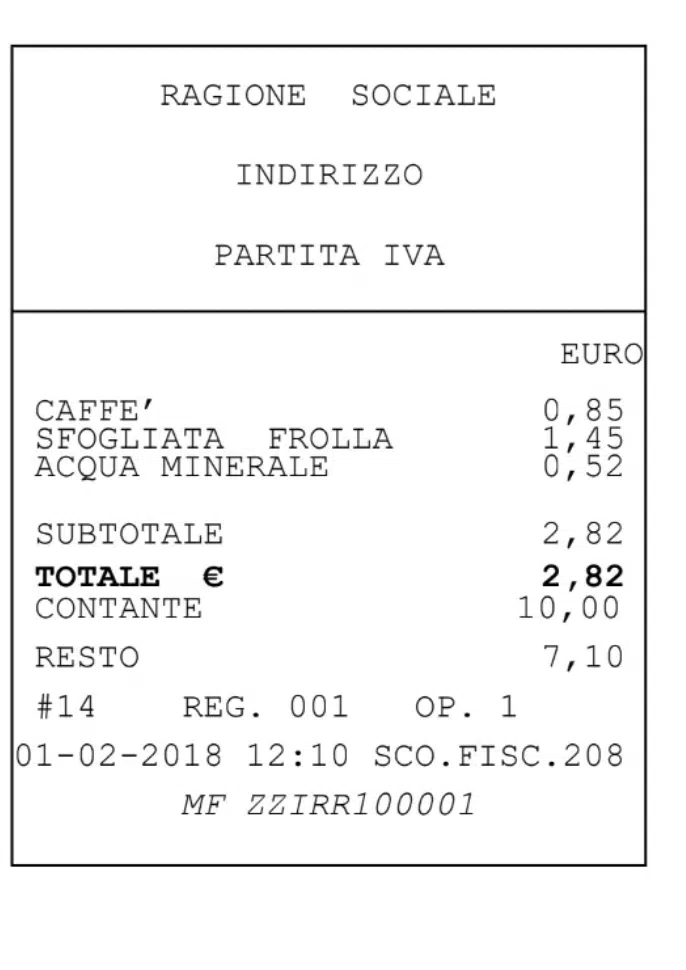


Tokens - Prompt: 1132, Response: 160, Total: 1292


## RAGIONE SOCIALE
**Date:** 2018-02-01 | **Payment:** cash | **Confidence:** High

| Item | Qty | Price |
|------|-----|-------|
| CAFFE' | 1 | 0.85 |
| SFOGLIATA FROLLA | 1 | 1.45 |
| ACQUA MINERALE | 1 | 0.52 |

**Subtotal:** 2.82 EUR
### Total: 2.82 EUR

In [7]:
# Scan a receipt - replace with your receipt image path
receipt_data = scan_receipt("images/receipt_example.jpg")
print_receipt_summary(receipt_data)

In [ ]:
# The raw JSON data - ready to be saved to a database or spreadsheet
print(json.dumps(receipt_data, indent=2, ensure_ascii=False))

## Compare Multiple Receipts

Scan several receipts and see a spending summary.

In [ ]:
def scan_multiple_receipts(image_paths):
    """Scan multiple receipts and return a spending summary."""
    results = []
    for path in image_paths:
        print(f"\n{'='*50}")
        data = scan_receipt(path)
        if data:
            results.append(data)
            print_receipt_summary(data)
    
    if not results:
        print("No receipts were successfully scanned.")
        return results
    
    # Spending summary
    total_spent = sum(r.get("total", 0) for r in results)
    lines = [
        "\n---",
        "## Spending Summary",
        f"**Receipts scanned:** {len(results)}",
        f"**Total spent:** {total_spent:.2f}",
        "",
        "| Store | Total |",
        "|-------|-------|"
    ]
    for r in results:
        lines.append(f"| {r.get('store_name', '?')} | {r.get('total', 0):.2f} |")
    
    display(Markdown("\n".join(lines)))
    return results

In [ ]:
# Add more receipt images to the images/ folder and list them here
# receipts = scan_multiple_receipts([
#     "images/receipt_1.jpg",
#     "images/receipt_2.jpg",
# ])

## Key Takeaways

1. **Vision API** can read and understand real-world images like receipts, not just food or faces
2. **Structured prompts** with clear output format (JSON) make the response parseable by code
3. **Base64 encoding** is how we send local images to OpenAI's API
4. **Confidence levels** help us know when the model is uncertain (blurry images, handwriting)
5. **Token usage** is higher with images - important to track for cost management